# **XÁC SUẤT THỐNG KÊ CHO AI**

In [125]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")

In [126]:
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## **Phần 1 - Thống kê mô tả & đặc trưng**

In [127]:
#Display first 5 rows
display(df.head(5))

#Number of rows and column
print(f"{df.shape[0]} rows")
print(f"{df.shape[1]} columns")

#Data types of each column
print("Data type of each column:")
print(df.dtypes)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


150 rows
5 columns
Data type of each column:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [128]:
numeric_columns = df.select_dtypes(include=[np.number])

calculation_df = pd.DataFrame()
calculation_df['mean'] = numeric_columns.mean()
calculation_df['median'] = numeric_columns.median()
calculation_df['mode'] = numeric_columns.mode().iloc[0]
calculation_df['var'] = numeric_columns.var()
calculation_df['std'] = numeric_columns.std()
calculation_df['min'] = numeric_columns.min()
calculation_df['max'] = numeric_columns.max()
calculation_df['Q1'] = numeric_columns.quantile(0.25)
calculation_df['Q3'] = numeric_columns.quantile(0.75)
calculation_df['IQR'] = calculation_df['Q3'] - calculation_df['Q1']

display(calculation_df)

grouped_df = df.groupby('species').agg(['mean', 'std'])
display(grouped_df)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

### **Nhận xét: Nhóm Setosa khác biệt rõ nhất so với 2 nhóm còn lại là Versicolor và Virginica**
* Nhóm Setosa có chiều dài đài hoa (sepal length) ngắn hơn và chiều rộng đài hoa (sepal width) rộng hơn hẳn so với 2 nhóm còn lại.
* Nhóm Setosa còn có cánh hoa (petal) ngắn và hẹp hơn rất nhiều so với 2 nhóm còn lại.
* Ngoài ra độ lệch chuẩn (std) của các thông số về chiều dài và chiều rộng của cánh hoa và đài hoa của nhóm Setosa là nhỏ nhất cho thấy các hoa thuộc nhóm Setosa đồng đều về kích thước nhất trong 3 nhóm.

## **Phần 2 - Phân phối xác suất**

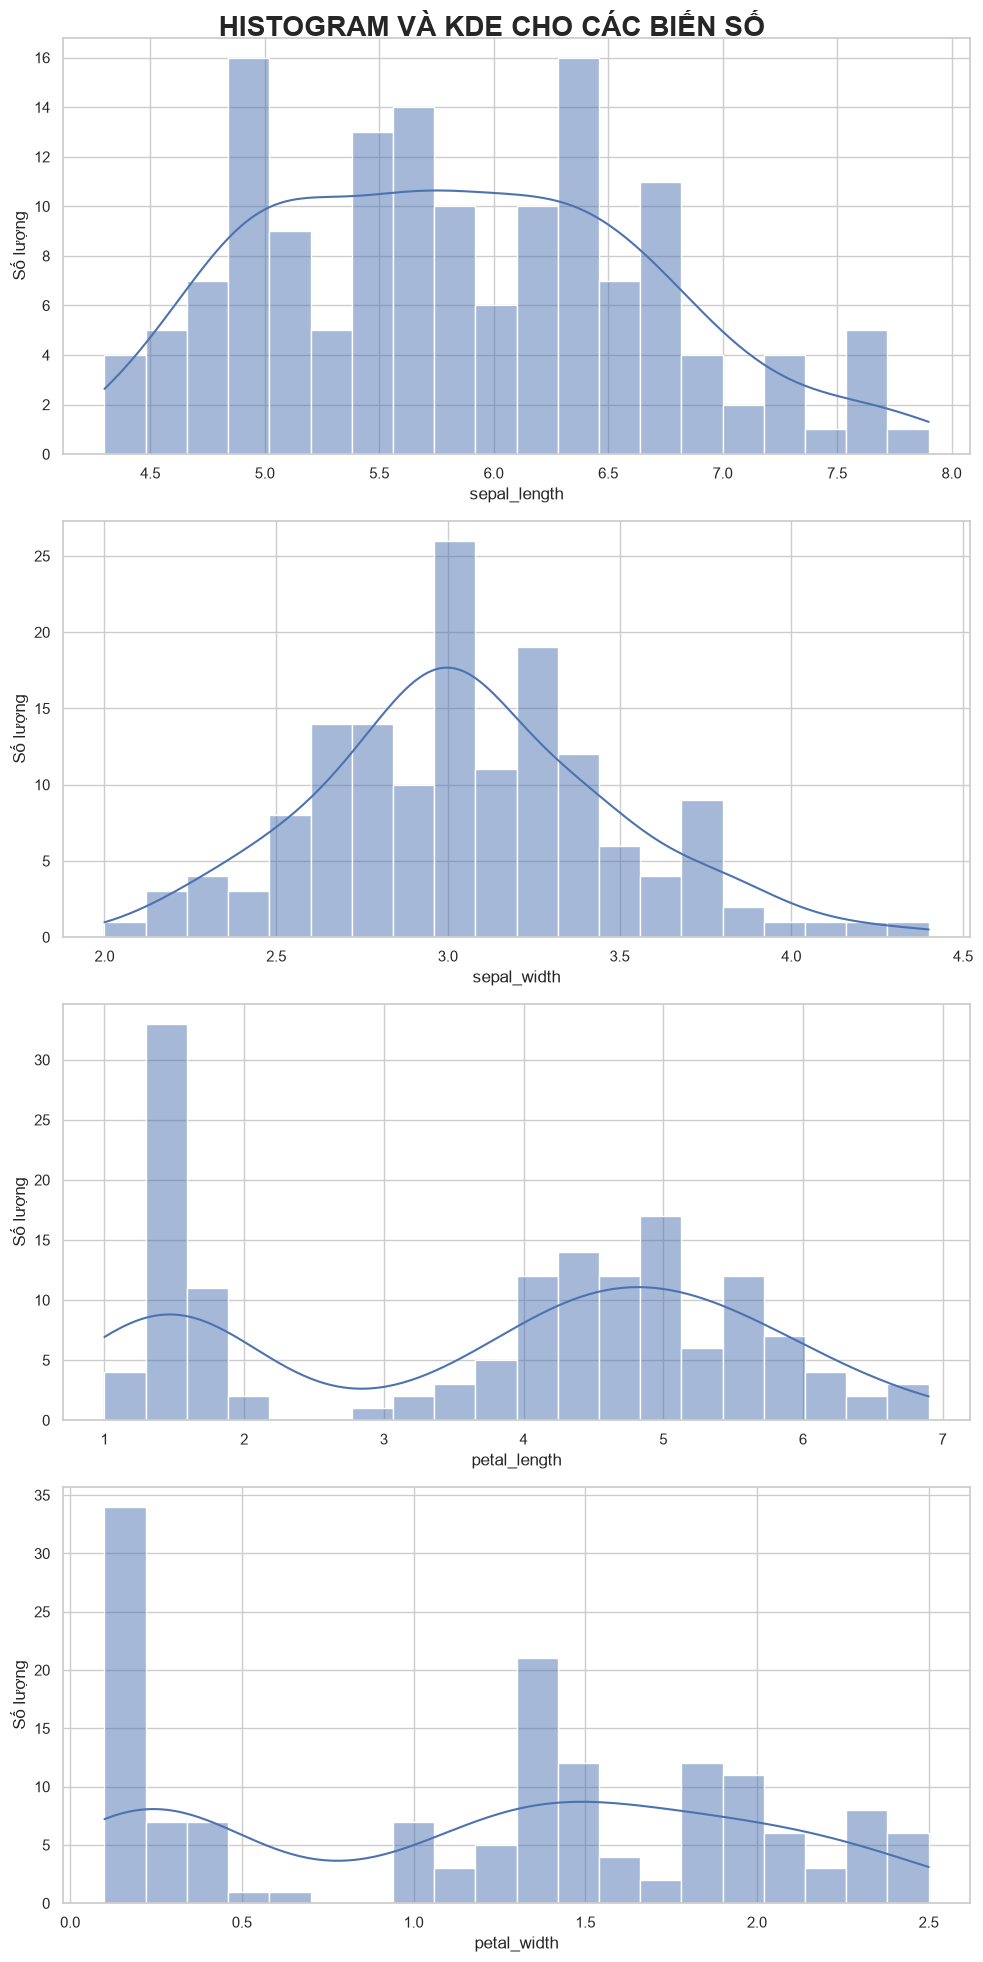

In [129]:
#Histogram and KDE for sepal and petal size
cols_num = numeric_columns.shape[1]

fig, axes = plt.subplots(cols_num, 1, figsize=(10, 5*cols_num))
fig.suptitle("HISTOGRAM VÀ KDE CHO CÁC BIẾN SỐ", fontsize=20, fontweight='bold')

for i, col in enumerate(numeric_columns, start=0):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()


### **Nhận xét:**
* `sepal_length`: Phân phối lệch phải, các đỉnh nhô ra nhẹ nhưng không quá khác biệt, phân phối vẫn tập trung ở giữa.
* `sepal_width`: Có hình dáng chuông cân xứng, lệch phải nhẹ.
* `petal_length`: Phân phối có 2 đỉnh, có thể suy ra từ sự khác biệt giữa loài `setosa` và 2 loài còn lại.
* `petal_width`: Phân phối gần như tương tự `petal_length`.

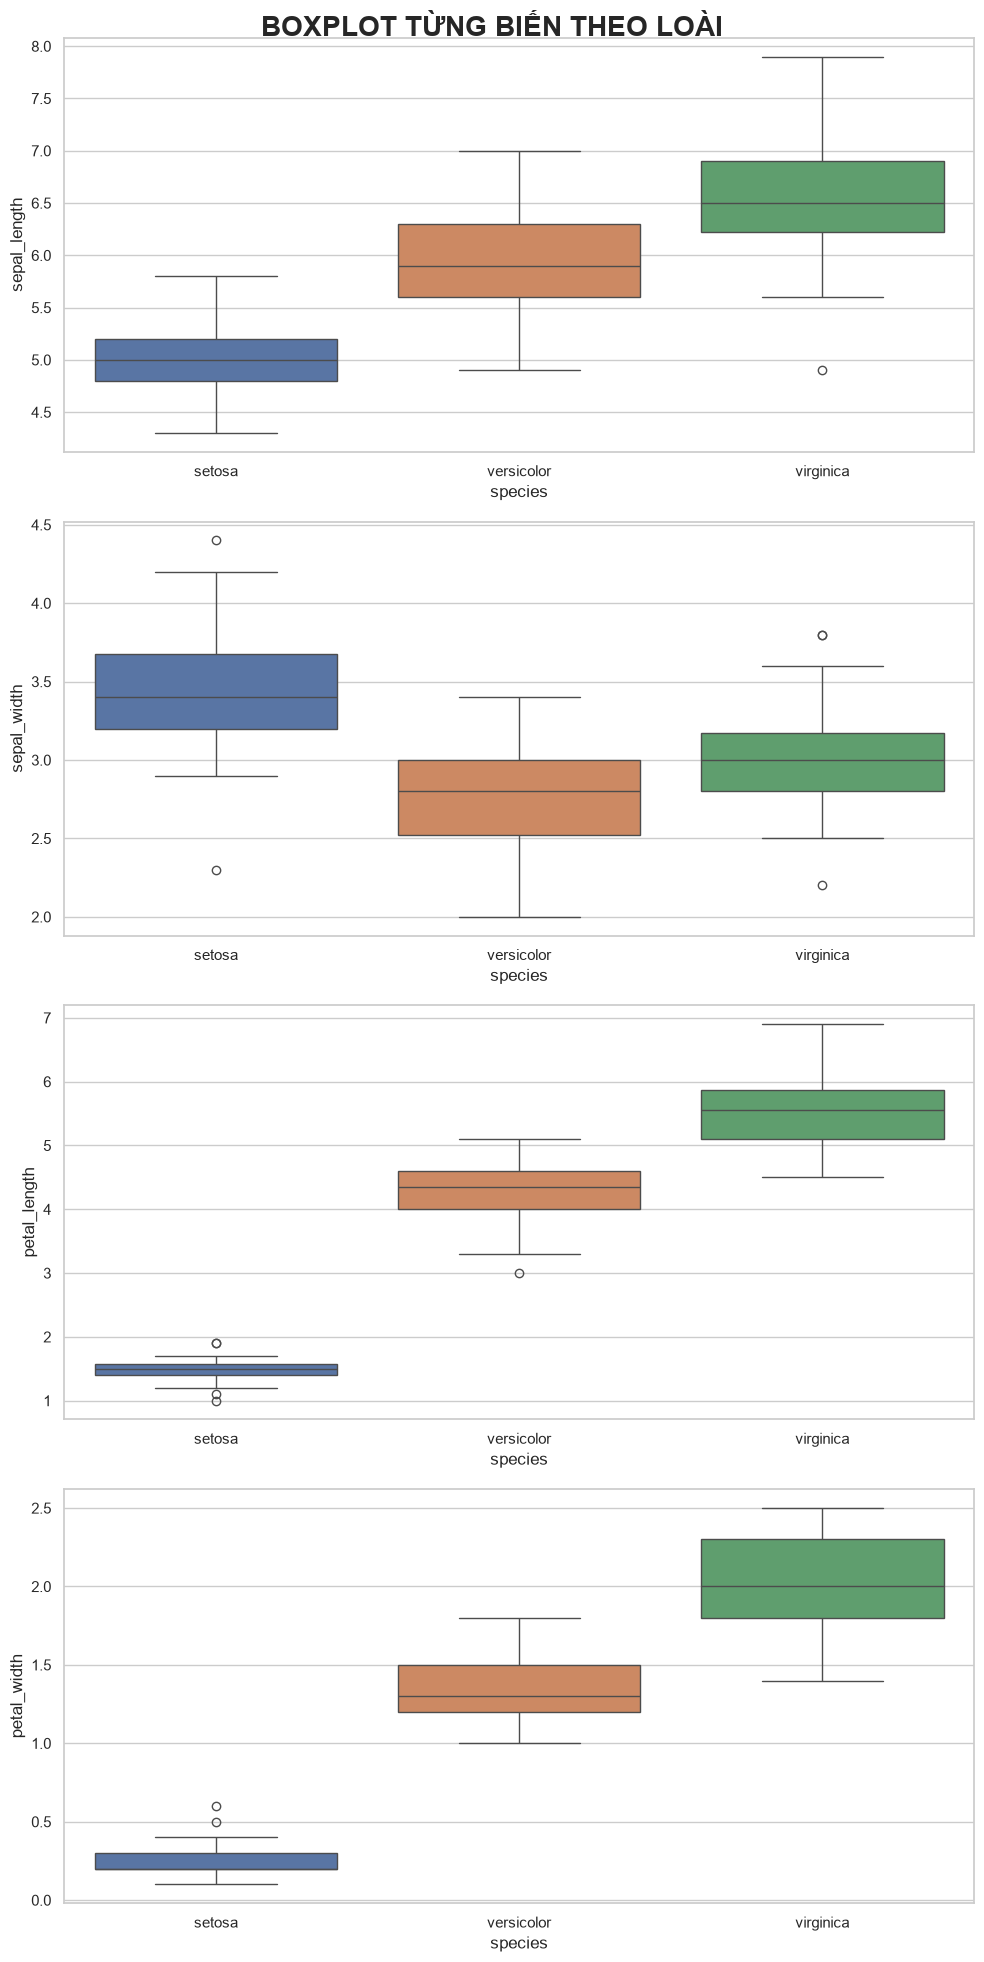

In [130]:
#Boxplot
cols_num = numeric_columns.shape[1]

fig, axes = plt.subplots(cols_num, 1, figsize=(10, 5*cols_num))
fig.suptitle("BOXPLOT TỪNG BIẾN THEO LOÀI", fontsize=20, fontweight='bold')

for i, col in enumerate(numeric_columns, start=0):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], hue='species')

plt.tight_layout()
plt.show()

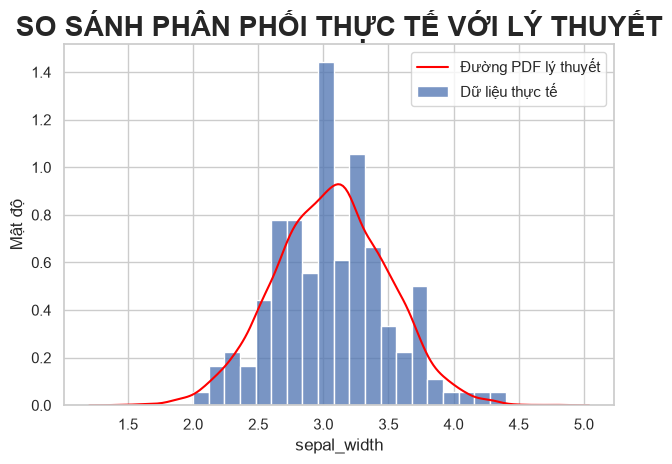

In [131]:
#Normal distribution compare with sepal_width
choosen_col = 'sepal_width'
choosen_col_mean = df[choosen_col].mean()
choosen_col_std = df[choosen_col].std()

normal_data = np.random.normal(choosen_col_mean, choosen_col_std, 10000)

sns.histplot(data=df[choosen_col], stat='density', bins=20, label="Dữ liệu thực tế")
sns.kdeplot(normal_data, color='red', label="Đường PDF lý thuyết")

plt.title("SO SÁNH PHÂN PHỐI THỰC TẾ VỚI LÝ THUYẾT", fontsize=20, fontweight='bold')
plt.ylabel("Mật độ")
plt.xlabel(choosen_col)
plt.legend()
plt.tight_layout()
plt.show()

### **Nhận xét:**
Histogram từ dữ liệu thực tế gần giống với đường PDF lý thuyết do đó phân phối của tập dữ liệu `sepal_width` xấp xỉ phân phối chuẩn.

## **Phần 3 - Phân tích đa biến & tương quan**

In [132]:
#Covariance and correlation matrices
cov_matrix = numeric_columns.cov()
corr_matrix = numeric_columns.corr()

print("Ma trận hiệp phương sai:")
display(cov_matrix)

print("Ma trận tương quan:")
display(corr_matrix)

Ma trận hiệp phương sai:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


Ma trận tương quan:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


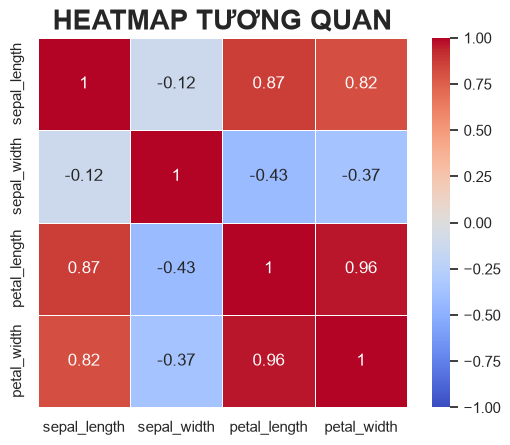

In [133]:
#Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmax=1, vmin=-1, center=0, square=True, linewidth=0.5)

plt.title("HEATMAP TƯƠNG QUAN", fontsize=20, fontweight='bold')
plt.show()

### **Nhận xét:**
* Cặp tương quan mạnh nhất là `petal_length` và `petal_width` với hệ số tương quan dương là $0,96$. Hệ số tương quan này phù hợp với đặc điểm sinh học cánh hoa càng dài thì bề rộng cánh hoa càng rộng và ngược lại.
* Có dấu hiệu đa cộng tuyến giữa `petal_length` và `petal_width`.

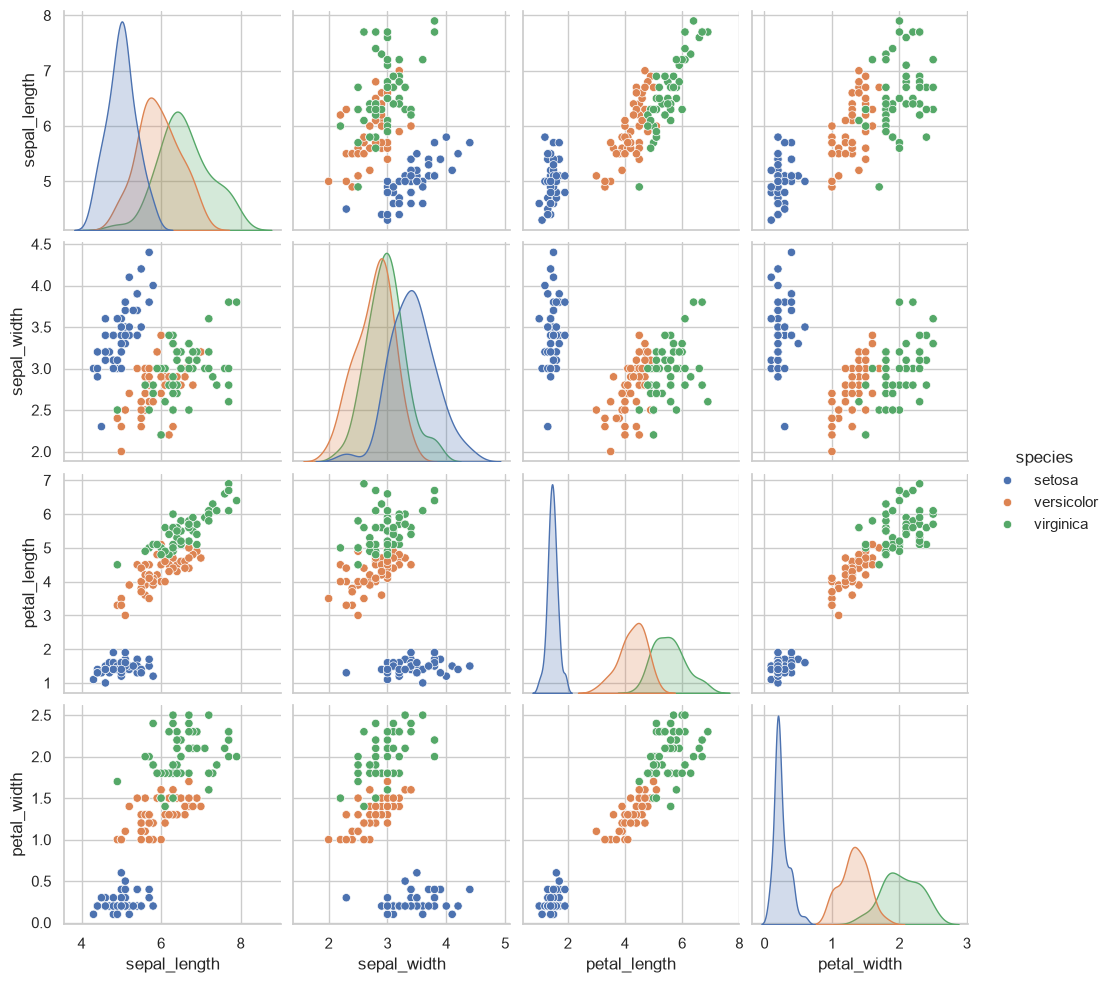

In [134]:
#Pairplot
sns.pairplot(df, hue='species')
plt.show()

### **Nhận xét:**
Đối với mỗi cặp biến, cụm dữ liệu của loài `setosa` hoàn toàn tách biệt với 2 loài `versicolor` và `virginica`. Trong khi đó cụm dữ liệu 2 loài `versicolor` và `virginica` nằm rất gần nhau và có nhiều điểm giao nhau ở các cặp biến (nhiều nhất là ở độ dài và độ rộng đài hoa) cho thấy mối quan hệ gần gũi giữa 2 loài này.

## **Phần 4 - Xác suất & Định lý Bayes**

Tỷ lệ mắc bệnh khi có xét nghiệm dương tính: 0.1667


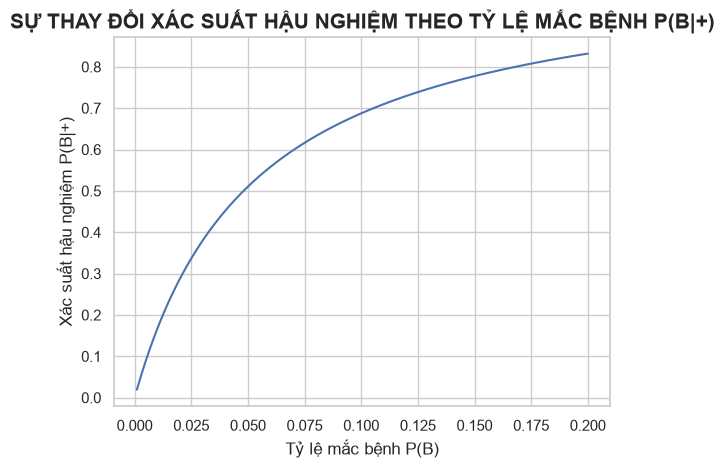

In [135]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print(f"Tỷ lệ mắc bệnh khi có xét nghiệm dương tính: {round(P_B_given_pos, 4)}")

P_B_arr = np.linspace(0.001, 0.2, 100)

P_pos_arr = P_pos_givenB * P_B_arr + P_pos_givenNB * (1 - P_B_arr)
P_B_given_pos_arr = P_pos_givenB * P_B_arr / P_pos_arr

plt.title("SỰ THAY ĐỔI XÁC SUẤT HẬU NGHIỆM THEO TỶ LỆ MẮC BỆNH P(B|+)", fontsize=15, fontweight='bold')
plt.xlabel("Tỷ lệ mắc bệnh P(B)")
plt.ylabel("Xác suất hậu nghiệm P(B|+)")
plt.plot(P_B_arr, P_B_given_pos_arr)
plt.show()

### **Nhận xét:**
* Đối với trường hợp tỷ lệ mắc bệnh là $0,01$ và tỷ lệ xét nghiệm dương tính đúng là $0,99$ kết quả xác suất bị mắc bệnh khi có kết quả dương tính lại thấp hơn trực giác $0,1667$, điều này hoàn toàn đúng vì khi này tỷ lệ không mắc bệnh vẫn chiếm tỷ lệ đông và đông hơn rất nhiều so với tỷ lệ mắc bệnh, do đó dù xác suất xét nghiệm dương tính bị sai, tỷ lệ người không mắc bệnh sau khi xét nghiệm dương tính vẫn chiếm phần nhiều so với người mắc bệnh sau xét nghiệm dương tính.
* Đồ thị dốc lên tương ứng với ý nghĩa nếu tỷ lệ mắc bệnh tăng, nhìn chung xác suất thực sự mắc bệnh nếu xét nghiệm dương tính sẽ tăng. Tuy nhiên, khi tăng tỷ lệ mắc bệnh trong khoảng nhỏ bắt đầu từ $0,001$, độ dốc đồ thị là rất lớn với ý nghĩa rằng nếu tăng nhẹ tỷ lệ mắc bệnh của một căn bệnh rất hiếm, xác suất mắc bệnh nếu xét nghiệm dương tính sẽ tăng mạnh. Ngược lại, độ tăng độ dốc của đồ thị lại giảm, với ý nghĩa rằng nếu căn bệnh càng phổ biến, sự tăng xác suất thật sự mắc bệnh nếu tỷ lệ mắc bệnh tăng là không nhiều.

## **BONUS: Bộ lọc Naive Bayes**

In [137]:
#P(word|spam), P(word|ham)
words = {
    'quảng cáo': {'spam': 0.7, 'ham': 0.3},
    'chương trình': {'spam': 0.6, 'ham': 0.5},
    'khuyến mãi': {'spam': 0.45, 'ham': 0.1},
    'siêu sale': {'spam': 0.9, 'ham': 0.02}
}

def get_words_list(text):
    words = text.split()
    tokens = list(words)
    for i in range(0, len(words) - 1):
        tokens.append(f"{words[i]} {words[i + 1]}")
    return tokens

glob_P_spam = 0.3
glob_P_ham = 0.7

def naive_bayes_filter(email):
    P_spam = glob_P_spam
    P_ham = glob_P_ham
    tokens = get_words_list(email)
    for token in tokens:
        if token in words:
            P_word_spam = P_spam * words[token]['spam']
            P_word_ham = P_ham * words[token]['ham']
            new_space = P_word_spam + P_word_ham
            P_spam = P_word_spam / new_space
            P_ham = P_word_ham / new_space
    return P_spam

emails = [
    "quảng cáo ti vi chất lượng cao",
    "chương trình khuyến mãi siêu sale sập sàn",
    "chương trình khuyến mãi ngày 6/6",
    "siêu sale shopee ngày 6/6",
    "hưởng ứng tuần lễ học tập trọn đời"
]


for email in emails:
    probability = naive_bayes_filter(email)
    print(f"Email {email} có tỷ lệ spam: {round(probability, 4)}")

Email quảng cáo ti vi chất lượng cao có tỷ lệ spam: 0.5
Email chương trình khuyến mãi siêu sale sập sàn có tỷ lệ spam: 0.9905
Email chương trình khuyến mãi ngày 6/6 có tỷ lệ spam: 0.6983
Email siêu sale shopee ngày 6/6 có tỷ lệ spam: 0.9507
Email hưởng ứng tuần lễ học tập trọn đời có tỷ lệ spam: 0.3
